• Quais trechos de 1km nas rodovias federais têm densidade de acidentes fatais 3x acima da média nacional? 
 
• Sextas-feiras à noite concentram 30% dos acidentes com embriaguez, enquanto domingos à tarde têm mais colisões traseiras em retornos de viagem? 
 
• Horário de pico em rodovias de acesso às capitais: colisões traseiras são 70% dos acidentes?

Bibliotecas utilizadas

In [49]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [62]:
df_original = pd.read_csv("datatran/datatran_2023_2024_2025.csv")
df = df_original.copy()

C:\Users\Hanny\AppData\Local\Temp\ipykernel_10660\1045615583.py:1: DtypeWarning: Columns (25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original = pd.read_csv("datatran/datatran_2023_2024_2025.csv")


# PRÉ PROCESSAMENTO

### Transformação de Dados

In [63]:
df['km'] = df['km'].str.replace(',', '.', regex=False) # Trocando formatação decimal para evitar perda de dados
df['km'] = pd.to_numeric(df['km'], errors='coerce')

### Redução de Dimensionalidade

In [64]:
capitais_brasil = [
    "rio branco",
    "maceio",
    "macapa",
    "manaus",
    "salvador",
    "fortaleza",
    "brasilia",
    "vitoria",
    "goiania",
    "são luis",
    "cuiaba",
    "campo grande",
    "belo horizonte",
    "belem",
    "joão pessoa",
    "curitiba",
    "recife",
    "teresina",
    "rio de janeiro",
    "natal",
    "porto alegre",
    "porto velho",
    "boa vista",
    "florianopolis",
    "são paulo",
    "aracaju",
    "palmas"
]

def normalizar(texto):
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return texto

def municipio_to_capital(municipio):
    municipio = normalizar(municipio)

    if municipio in capitais_brasil:
        return 1
    else:
        return 0

df['capital'] = df['municipio'].apply(municipio_to_capital)

In [65]:
def classificar_macro_causa(causa):
    if pd.isna(causa):
        return "Outros"
    
    causa = causa.lower()
    
    # --- PEDRESTRE ---
    if "pedestre" in causa:
        return "Pedestre"
    
    # --- AMBIENTE ---
    if any(palavra in causa for palavra in [
        "chuva", "neblina", "fumaça", 
        "acumulo de água", "acumulo de óleo"
    ]):
        return "Ambiente"
    
    # --- MECÂNICA ---
    if any(palavra in causa for palavra in [
        "falhas mecânicas", "freio", "suspensão",
        "pneu", "faróis"
    ]):
        return "Mecânica"
    
    # --- VIA ---
    if any(palavra in causa for palavra in [
        "pista", "curva", "declive", "ondulação",
        "acostamento", "sinalização", "via",
        "obras", "drenagem", "desvio",
        "faixa", "acesso irregular",
        "semáforo com defeito",
        "elemento de contenção",
        "obstrução"
    ]):
        return "Via"
    
    # --- CONDUTOR ---
    if any(palavra in causa for palavra in [
        "condutor", "velocidade", "ultrapassagem",
        "manobra", "transitar", "conversão",
        "frear", "racha", "álcool",
        "reação", "mal súbito",
        "distância", "desrespeitou"
    ]):
        return "Condutor"
    
    return "Outros"


df["macro_causa"] = df["causa_acidente"].apply(classificar_macro_causa)

In [66]:
def mapa_clima(condicao):
    if pd.isna(condicao):
        return "Desconhecido"
    condicao = condicao.strip().lower()
    if condicao in ["céu claro", "sol", "vento"]:
        return "Normal"

    elif condicao in ["chuva", "garoa/chuvisco", "granizo", "neve", "nublado", "nevoeiro/neblina"]:
        return "Adversa"
    
    else:
        return "Desconhecido"
    
df["meteorologia"] = df["condicao_metereologica"].apply(mapa_clima)


In [67]:
def mapa_macro_tipo(tipo):
    if pd.isna(tipo):
        return "Outros"
    
    tipo = tipo.lower()
    
    # --- COLISÕES ENTRE VEÍCULOS ---
    if any(palavra in tipo for palavra in [
        "colisão frontal",
        "colisão traseira",
        "colisão transversal",
        "colisão lateral mesmo sentido",
        "colisão lateral sentido oposto",
        "engavetamento"
    ]):
        return "Colisão entre veículos"
    
    # --- COLISÃO COM OBJETO ---
    if any(palavra in tipo for palavra in [
        "colisão com objeto",
        "derramamento de carga"
    ]):
        return "Colisão com objeto"
    
    # --- PERDA DE CONTROLE / SAÍDA ---
    if any(palavra in tipo for palavra in [
        "saída de leito",
        "capotamento",
        "tombamento"
    ]):
        return "Perda de controle / saída de pista"
    
    # --- ATROPELAMENTO ---
    if "atropelamento" in tipo:
        return "Atropelamento"
    
    # --- SINISTRO INDIVIDUAL ---
    if any(palavra in tipo for palavra in [
        "queda de ocupante",
        "sinistro pessoal"
    ]):
        return "Sinistro individual"
    
    # --- OUTROS ---
    if any(palavra in tipo for palavra in [
        "incêndio",
        "eventos atípicos"
    ]):
        return "Outros"
    
    return "Outros"

df['macro_tipo'] = df['tipo_acidente'].apply(mapa_macro_tipo)

In [68]:
def mapa_fase_dia(fase):

    fase = fase.strip().lower()
    if fase in ["amanhecer", "pleno dia"]:
        return 1
    elif fase in ["plena noite", "anoitecer"]:
        return 0
    
df['dia'] = df['fase_dia'].apply(mapa_fase_dia)

In [69]:
def mapa_dia_semana(dia):

    dia = dia.strip().lower()
    if dia in ["segunda-feira", "terça-feira", "quarta-feira", "quinta-feira", "sexta-feira"]:
        return 1
    elif dia in ["sábado", "domingo"]:
        return 0

    
df['dia_util'] = df['dia_semana'].apply(mapa_dia_semana)

In [70]:
def rodovia_federal(br):
    if br != 0:
        return 1
    else:
        return 0

df['rodovia_federal'] = df['br'].apply(rodovia_federal)

In [71]:
colunas_remover = [
    'id',
    'data_inversa',
    'horario',
    'classificacao_acidente',
    'condicao_metereologica',
    'sentido_via',
    'tracado_via',
    'uso_solo',
    'pessoas',
    'feridos_leves',
    'feridos_graves',
    'ilesos',
    'ignorados',
    'veiculos',
    'latitude',
    'longitude',
    'regional',
    'delegacia',
    'uop',
    'municipio',
    'uf',
    'br',
    'causa_acidente',
    'tipo_acidente',
    'fase_dia',
    'dia_semana'
]

df = df.drop(columns=colunas_remover)

### Amostragem Aleatória Simples

foi necessário realizar uma amostragem para execução de alguns algoritmos de maior complexidade de O

In [36]:
df_sample = df.sample(20000, random_state=42)
df_sample

,km,tipo_pista,mortos,feridos,capital,rodovia_federal,macro_causa,meteorologia,periodo_dia,dia_semana_categorizado,macro_tipo
51217,281.0,Simples,0,1,0,1,Condutor,Normal,dia,Fim de Semana,Colisão entre veículos
41702,124.4,Simples,1,0,0,1,Pedestre,Normal,Noite,Fim de Semana,Atropelamento
203655,120.0,Dupla,0,1,0,1,Condutor,Adversa,dia,Fim de Semana,Perda de controle / saída de pista
196603,32.3,Dupla,0,1,0,1,Pedestre,Normal,dia,Semana,Atropelamento
147195,408.0,Simples,0,2,0,1,Via,Normal,dia,Semana,Colisão entre veículos
...,...,...,...,...,...,...,...,...,...,...,...
1684,278.0,Dupla,0,1,0,1,Condutor,Adversa,Noite,Fim de Semana,Colisão entre veículos
67679,155.1,Simples,0,5,0,1,Outros,Normal,Noite,Semana,Colisão entre veículos
170271,13.0,Simples,0,1,0,1,Condutor,Adversa,Noite,Semana,Colisão entre veículos
143555,4.2,Dupla,0,1,0,1,Via,Normal,dia,Semana,Colisão entre veículos


### One-Hot Encoding

foi necessário realizar transformação de atributos categóricos em numéricos para execução de algoritmos baseados em distância

In [72]:
categoricas = [
    'macro_causa',
    'macro_tipo',
    'tipo_pista',
    'meteorologia'
]

df_encoded = pd.get_dummies(df, columns=categoricas, drop_first=False)
df_encoded

,km,mortos,feridos,capital,dia,dia_util,rodovia_federal,macro_causa_Ambiente,macro_causa_Condutor,macro_causa_Mecânica,...,macro_tipo_Colisão entre veículos,macro_tipo_Outros,macro_tipo_Perda de controle / saída de pista,macro_tipo_Sinistro individual,tipo_pista_Dupla,tipo_pista_Múltipla,tipo_pista_Simples,meteorologia_Adversa,meteorologia_Desconhecido,meteorologia_Normal
0,114.0,0,1,0,0,0,1,False,True,False,...,False,False,True,False,False,False,True,False,False,True
1,113.1,1,0,0,0,0,1,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,1112.0,0,1,0,0,0,1,False,True,False,...,False,False,True,False,False,False,True,False,True,False
3,314.8,0,0,0,1,0,1,False,True,False,...,False,False,True,False,True,False,False,False,False,True
4,569.4,0,2,0,1,0,1,True,False,False,...,True,False,False,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213413,265.0,0,2,0,1,1,1,False,True,False,...,True,False,False,False,True,False,False,False,False,True
213414,141.0,0,0,0,1,1,1,False,False,True,...,False,False,True,False,True,False,False,False,False,True
213415,127.0,0,1,0,1,0,1,False,True,False,...,False,False,True,False,True,False,False,False,False,True
213416,575.1,0,2,0,0,1,1,False,True,False,...,False,False,True,False,False,False,True,False,False,True


### Normalização

foi necessário realizar normalização dos atributos para execução de algoritmos baseados em distância

In [76]:
cols_continuas = ['km', 'mortos', 'feridos']

scaler = StandardScaler()
df_encoded[cols_continuas] = scaler.fit_transform(df_encoded[cols_continuas])

df_scaled = df_encoded

print(df_encoded)

              km    mortos   feridos  capital  dia  dia_util  rodovia_federal  \
0      -0.639751 -0.239688 -0.128196        0    0         0                1   
1      -0.643711  2.629607 -0.955390        0    0         0                1   
2       3.751937 -0.239688 -0.128196        0    0         0                1   
3       0.243867 -0.239688 -0.955390        0    1         0                1   
4       1.364232 -0.239688  0.698997        0    1         0                1   
...          ...       ...       ...      ...  ...       ...              ...   
213413  0.024723 -0.239688  0.698997        0    1         1                1   
213414 -0.520937 -0.239688 -0.955390        0    1         1                1   
213415 -0.582544 -0.239688 -0.128196        0    1         0                1   
213416  1.389315 -0.239688  0.698997        0    0         1                1   
213417 -0.164498 -0.239688 -0.128196        0    1         0                1   

        macro_causa_Ambient

# ANÁLISE EXPLORATÓRIA

### Descrição e histogramas

A partir da descrição dos dados, é observável que a maioria dos acidentes reportados não constaram óbitos, mas tiveram ao menos um ferido. Ao mesmo tempo, nota-se a grande discrepância entre essas contagens, assumindo em casos extremos valores como 37 e 84 mortos e feridos, respectivamente.

              mortos        feridos             km
count  213418.000000  213418.000000  213418.000000
mean        0.083536       1.154978     259.381732
std         0.348519       1.208910     227.248023
min         0.000000       0.000000       0.000000
25%         0.000000       1.000000      76.000000
50%         0.000000       1.000000     193.600000
75%         0.000000       1.000000     407.275000
max        37.000000      84.000000    1470.000000


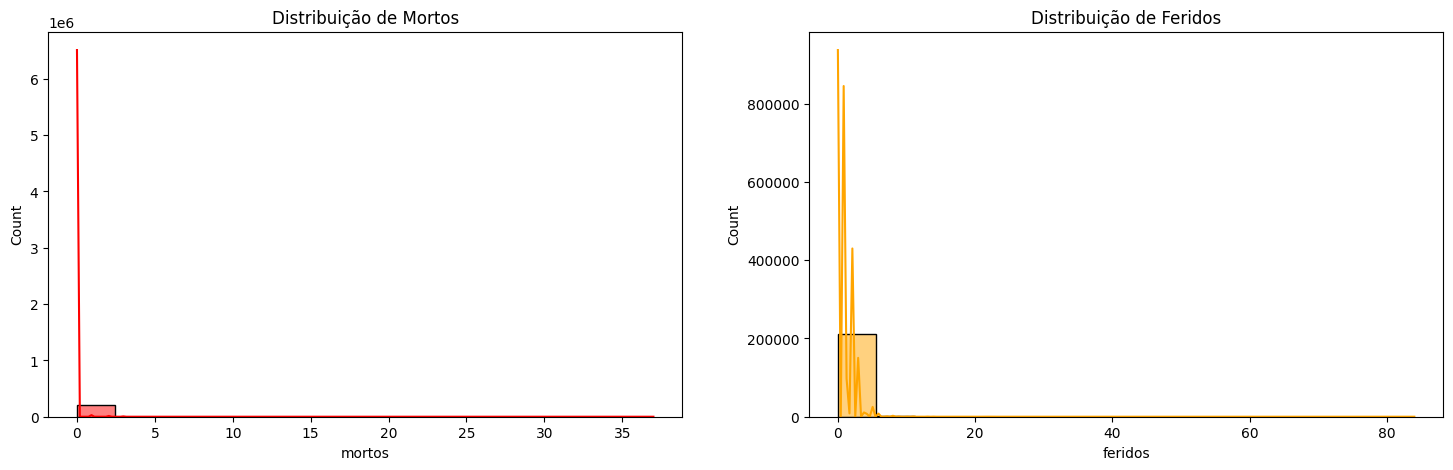

In [77]:
print(df[['mortos', 'feridos', 'km']].describe())

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(df['mortos'], bins=15, ax=axes[0], kde=True, color='red')
axes[0].set_title('Distribuição de Mortos')

sns.histplot(df['feridos'], bins=15, ax=axes[1], kde=True, color='orange')
axes[1].set_title('Distribuição de Feridos')

plt.show()

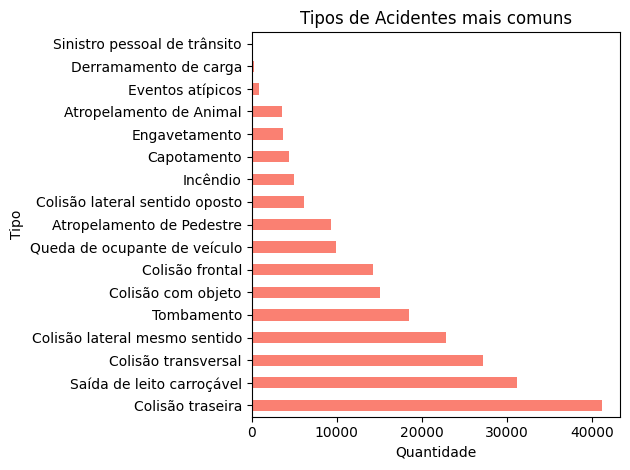

In [78]:
# Histograma para Tipo de Acidente (Horizontal)
df_original['tipo_acidente'].value_counts().plot(kind='barh', color='salmon')

plt.title('Tipos de Acidentes mais comuns')
plt.xlabel('Quantidade')
plt.ylabel('Tipo')
plt.tight_layout() # Ajusta o layout para não cortar o texto
plt.show()

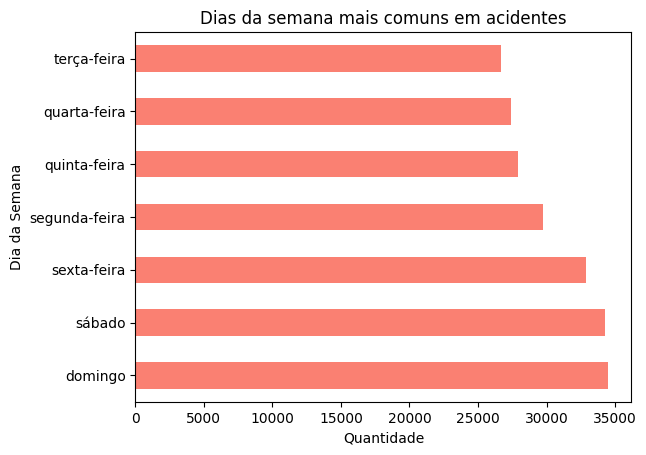

In [79]:
df_original['dia_semana'].value_counts().plot(kind='barh', color='salmon')

plt.title('Dias da semana mais comuns em acidentes')
plt.xlabel('Quantidade')
plt.ylabel('Dia da Semana')
plt.show()

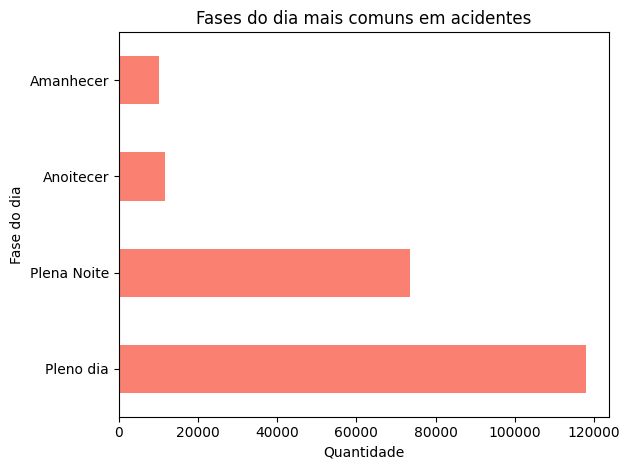

In [43]:
df_original['fase_dia'].value_counts().plot(kind='barh', color='salmon')

plt.title('Fases do dia mais comuns em acidentes')
plt.xlabel('Quantidade')
plt.ylabel('Fase do dia')
plt.tight_layout() 
plt.show()

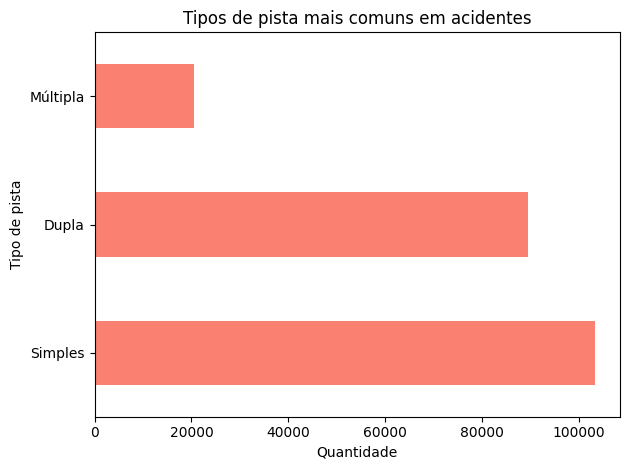

In [ ]:
df_original['tipo_pista'].value_counts().plot(kind='barh', color='salmon')

plt.title('Tipos de pista mais comuns em acidentes')
plt.xlabel('Quantidade')
plt.ylabel('Tipo de pista')
plt.tight_layout() 
plt.show()

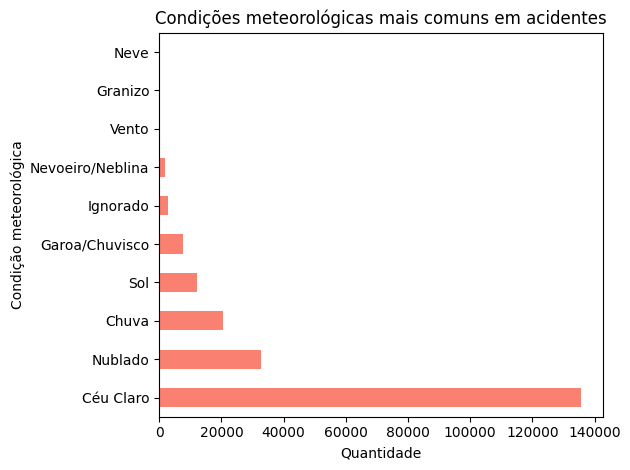

In [45]:
df_original['condicao_metereologica'].value_counts().plot(kind='barh', color='salmon')

plt.title('Condições meteorológicas mais comuns em acidentes')
plt.xlabel('Quantidade')
plt.ylabel('Condição meteorológica')
plt.tight_layout() 
plt.show()

A maioria dos acidentes reportados aconteceram durante a tarde em dias úteis. No entanto, os acidentes graves estão majoritariamente concentrados nas sextas e finais de semana à noite

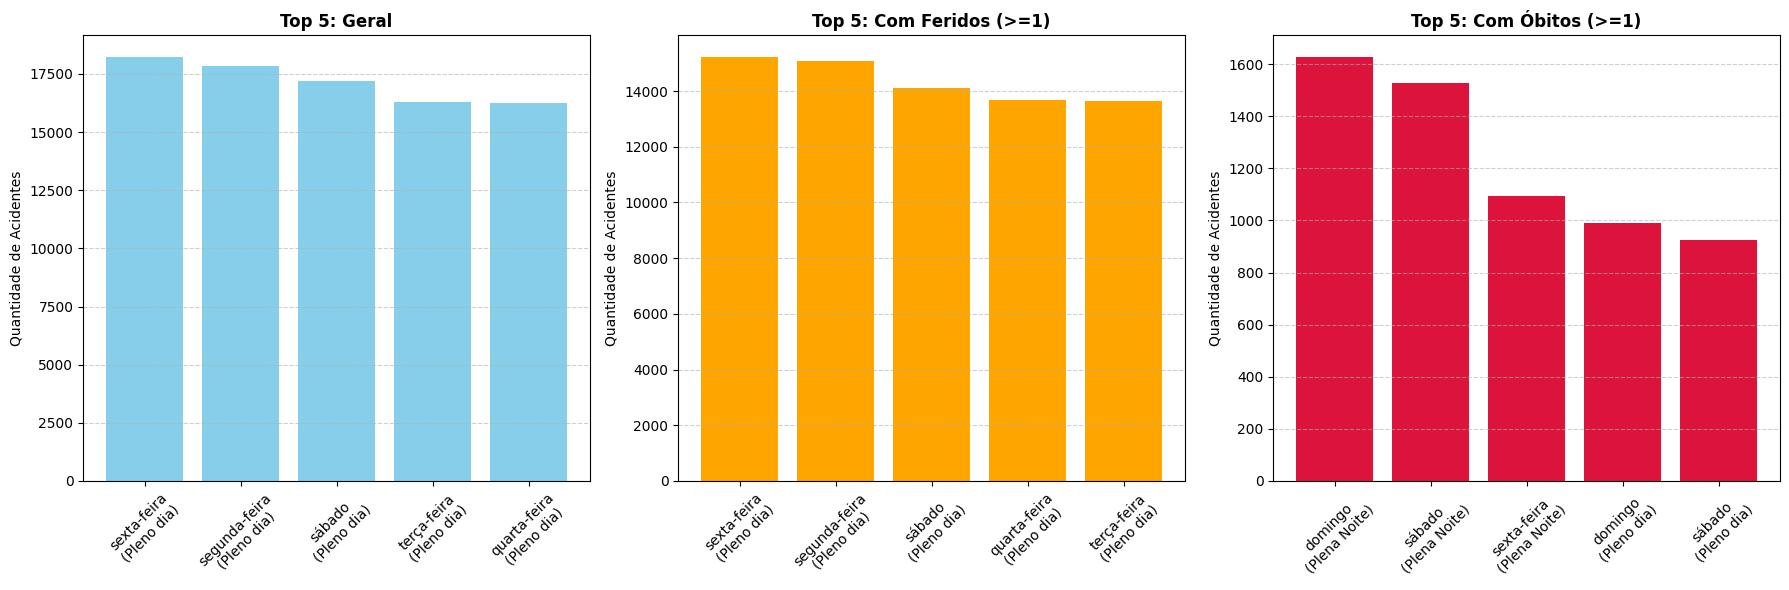

In [50]:
def pegar_top5(dataframe):
    temp = dataframe.groupby(['dia_semana', 'fase_dia']).size().reset_index(name='contagem')
    temp = temp.sort_values(by='contagem', ascending=False).head(5)
    temp['legenda'] = temp['dia_semana'] + "\n(" + temp['fase_dia'] + ")"
    return temp

df_geral = pegar_top5(df_original)
df_feridos = pegar_top5(df_original[df_original['feridos'] >= 1]) 
df_obitos = pegar_top5(df_original[df_original['mortos'] >= 1])   

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].bar(df_geral['legenda'], df_geral['contagem'], color='skyblue')
ax[0].set_title('Top 5: Geral', fontweight='bold')

ax[1].bar(df_feridos['legenda'], df_feridos['contagem'], color='orange')
ax[1].set_title('Top 5: Com Feridos (>=1)', fontweight='bold')

ax[2].bar(df_obitos['legenda'], df_obitos['contagem'], color='crimson')
ax[2].set_title('Top 5: Com Óbitos (>=1)', fontweight='bold')

for a in ax:
    a.tick_params(axis='x', rotation=45)
    a.set_ylabel('Quantidade de Acidentes')
    a.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.show()

### Boxplot

Os plots de **mortos** e **feridos** contém grande concentração próximas de zero, indicando que a grande maioria dos registros não causaram óbito ou ferimento. Ambos também apresentam grande quantidade de outliers.

A análise do boxplot de **mortos** demonstra que apesar dos acidentes com vítimas serem exceção, podem atingir uma grande proporção de vítimas quando ocorrem.

No caso de **feridos**, há uma concentração maior de ocorrências de cerca de um a quarenta feridos. Com o caso mais extremo constando 80 feridos.

Já a análise da **quilometragem** demonstra que metade dos registros ocorreu antes dos 200km rodados, e a outra metade depois. A maior parte dos eventos ocorre entre 100 e 400km. Mas apesar de haver uma forte concentração de dados no início das rodovias, a base de dados cobre acidentes ocorridos em maiores extensões, chegando a trechos mais remotos

In [48]:
print("oi")

oi


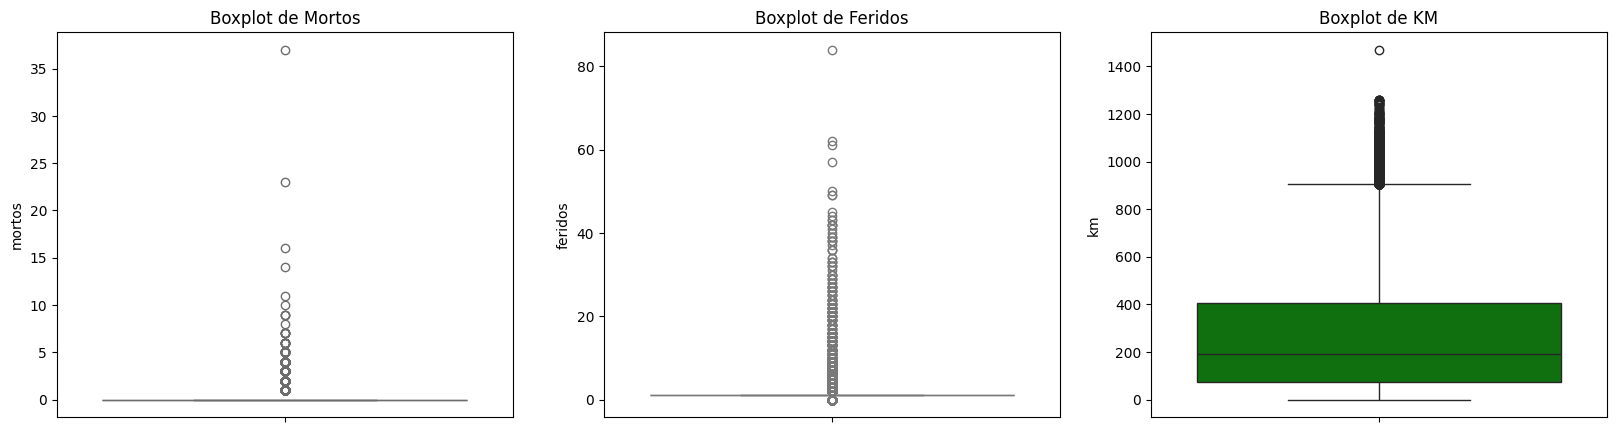

In [52]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=df, y='mortos', color='salmon')
plt.title('Boxplot de Mortos')

plt.subplot(1, 3, 2)
sns.boxplot(data=df, y='feridos', color='lightblue')
plt.title('Boxplot de Feridos')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, y='km', color='green')
plt.title('Boxplot de KM')

plt.show()

#### Análise de Outliers com base no Bloxpot

De acordo com a regra de IQR, qualquer acidente que contenha mortos e feridos são considerados outliers. No entanto, devido ao nosso interesse em analisar um cluster de acidentes graves, optamos pela não remoção destes.

In [19]:
# Regra de IQR (Tukey)

Q1 = df['mortos'].quantile(0.25)
Q3 = df['mortos'].quantile(0.75)
IQR = Q3 - Q1 # IQR (Intervalo Interquantil): mede a dispersão dos 50% centráis 

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['mortos'] < limite_inferior) | (df['mortos'] > limite_superior)]

print("outliers são aqueles com número de mortos menor que", limite_inferior, "ou maior que", limite_superior)

outliers são aqueles com número de mortos menor que 0.0 ou maior que 0.0


In [20]:
# Regra de IQR (Tukey)

Q1 = df['feridos'].quantile(0.25)
Q3 = df['feridos'].quantile(0.75)
IQR = Q3 - Q1 # IQR (Intervalo Interquantil): mede a dispersão dos 50% centráis 

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['feridos'] < limite_inferior) | (df['feridos'] > limite_superior)]

print("Outliers são aqueles com número de feridos menor que", limite_inferior, "ou maior que", limite_superior)

Outliers são aqueles com número de feridos menor que 1.0 ou maior que 1.0


In [21]:
# Regra de IQR (Tukey)

Q1 = df['km'].quantile(0.25)
Q3 = df['km'].quantile(0.75)
IQR = Q3 - Q1 # IQR (Intervalo Interquantil): mede a dispersão dos 50% centráis 

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['km'] < limite_inferior) | (df['km'] > limite_superior)]

print("Número de outliers:", len(outliers))

Número de outliers: 2264


Para análise de ruído das informações de quilometragem, os outliers foram analisados para garantia de coerência quanto ao tamanho das br's às quais se associam. <br>
Foram pesquisadas as extensões médias das br's:

BR-101 = 4.650 km <br>
BR-116 = 4.610 km <br>
BR-163 = 4.470 km <br>
BR-174 = 3.200 km <br>
BR-230 = 4.260 km <br>
BR-242 = 1.580 km <br>
BR-262 = 2.295 km <br>
BR-349 = 1.100 km <br>
BR-364 = 4.300 km <br>
BR-381 = 1.180 km <br>

In [22]:
top_km = df_original.sort_values(by="km", ascending=False).head(len(outliers))

br_mais_percorridas = top_km['br'].unique()

br_mais_percorridas.tolist()


[230, 364, 174, 163, 349, 101, 381, 242, 116, 262]

In [23]:
maiores_valores_br = df_original[df_original["br"].isin(br_mais_percorridas)].groupby("br").max("km").reset_index()
maiores_valores_br

,br,id,km,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,capital,rodovia_federal
0,101,748976.0,954.0,52,10,41,18,50,16,49,31,1,1
1,116,748948.0,933.0,71,37,42,30,71,23,44,20,1,1
2,163,748812.0,1114.0,69,11,61,22,57,12,62,16,1,1
3,174,742851.0,1139.0,55,7,34,11,42,6,45,10,1,1
4,230,749028.0,1470.0,50,6,29,13,49,8,33,9,1,1
5,242,745386.0,939.0,53,9,31,9,46,11,38,12,0,1
6,262,748731.0,913.1,60,4,19,11,60,12,27,14,1,1
7,349,744428.0,1103.0,22,4,6,5,21,5,6,7,1,1
8,364,748707.0,1258.0,61,5,26,12,46,14,26,20,1,1
9,381,748489.0,949.5,68,7,41,23,55,12,42,19,1,1


### Rankeamento de acidentes graves

In [53]:
print("Acidentes com maior número de óbitos:")
display(df.nlargest(5, 'mortos'))

print("Acidentes com maior número de feridos:")
display(df.nlargest(5, 'feridos'))

Acidentes com maior número de óbitos:


,km,tipo_pista,mortos,feridos,capital,rodovia_federal,macro_causa,meteorologia,periodo_dia,dia_semana_categorizado,macro_tipo
86272,286.5,Simples,37,13,0,1,Outros,Normal,Noite,Fim de Semana,Colisão entre veículos
68690,385.9,Simples,23,9,0,1,Condutor,Normal,Noite,Fim de Semana,Colisão entre veículos
204845,127.0,Simples,16,21,0,1,Condutor,Normal,Noite,Semana,Perda de controle / saída de pista
85803,0.0,Simples,14,1,0,1,Via,Normal,dia,Fim de Semana,Sinistro individual
151791,648.0,Simples,11,42,0,1,Condutor,Normal,Noite,Semana,Colisão entre veículos


Acidentes com maior número de feridos:


,km,tipo_pista,mortos,feridos,capital,rodovia_federal,macro_causa,meteorologia,periodo_dia,dia_semana_categorizado,macro_tipo
86251,260.0,Simples,5,84,0,1,Condutor,Normal,Noite,Semana,Colisão com objeto
2963,550.0,Simples,3,62,0,1,Condutor,Adversa,Noite,Semana,Colisão entre veículos
14996,138.4,Dupla,0,61,0,1,Condutor,Normal,Noite,Semana,Colisão entre veículos
140902,678.9,Simples,4,57,0,1,Condutor,Adversa,Noite,Semana,Perda de controle / saída de pista
54666,15.0,Dupla,2,50,0,1,Condutor,Adversa,Noite,Semana,Perda de controle / saída de pista


### Matriz de Correlação

Foi observado que não há ocorrência de variáveis altamente correlacionadas dentre os atributos que escolhemos para prosseguir a análise. Dessa forma, a redução de redundância não se fez necessária.

In [85]:
df_encoded.columns.tolist()

['km',
 'mortos',
 'feridos',
 'capital',
 'dia',
 'dia_util',
 'rodovia_federal',
 'macro_causa_Ambiente',
 'macro_causa_Condutor',
 'macro_causa_Mecânica',
 'macro_causa_Outros',
 'macro_causa_Pedestre',
 'macro_causa_Via',
 'macro_tipo_Atropelamento',
 'macro_tipo_Colisão com objeto',
 'macro_tipo_Colisão entre veículos',
 'macro_tipo_Outros',
 'macro_tipo_Perda de controle / saída de pista',
 'macro_tipo_Sinistro individual',
 'tipo_pista_Dupla',
 'tipo_pista_Múltipla',
 'tipo_pista_Simples',
 'meteorologia_Adversa',
 'meteorologia_Desconhecido',
 'meteorologia_Normal']

In [60]:
colunas_interesse = ['mortos', 'feridos', 'km', 'capital'] + [c for c in df_encoded.columns if 'dia_semana' in c or 'fase_dia' in c or 'meteorologia' in c or 'tipo_pista' in c]
colunas_interesse

['mortos',
 'feridos',
 'km',
 'capital',
 'tipo_pista_Dupla',
 'tipo_pista_Múltipla',
 'tipo_pista_Simples',
 'meteorologia_Adversa',
 'meteorologia_Desconhecido',
 'meteorologia_Normal',
 'dia_semana_categorizado_Fim de Semana',
 'dia_semana_categorizado_Semana']

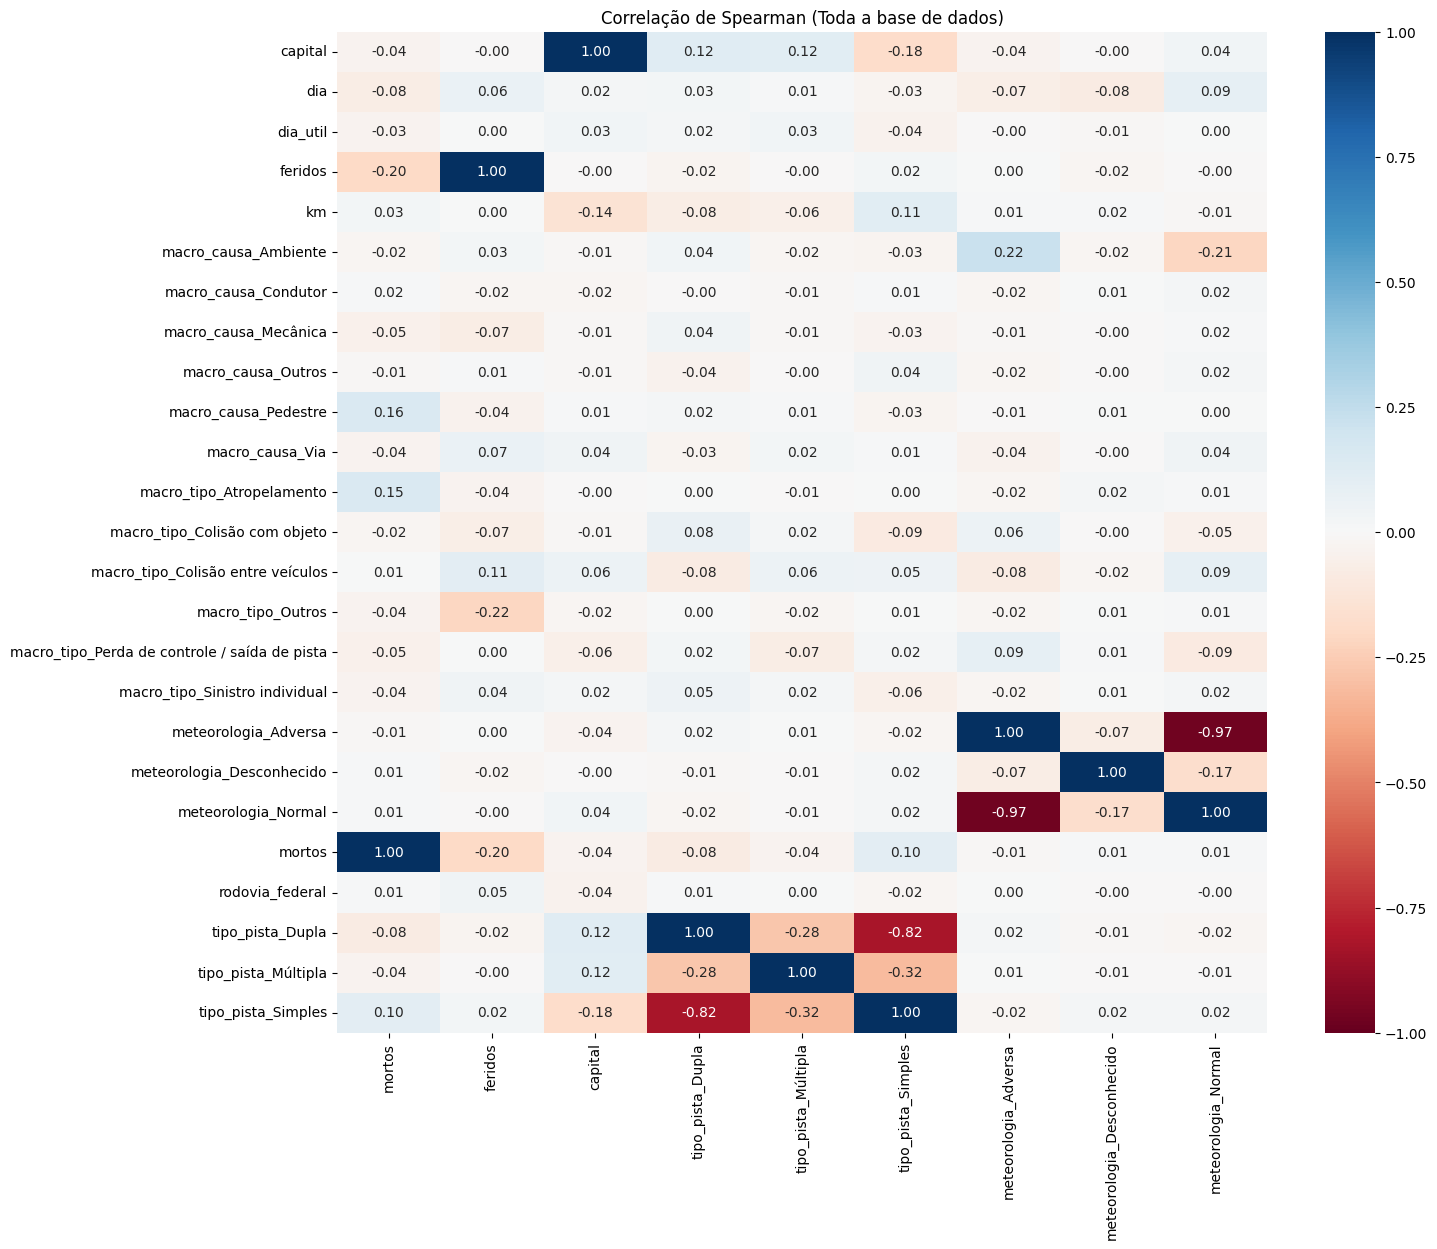

In [81]:
# Selecionando apenas as colunas relacionadas a vítimas, quilometragem, dia de semana e fase do dia
colunas_interesse = ['mortos', 'feridos', 'km', 'capital', 'rodovia_federal', 'dia', 'dia_util'] + [c for c in df_encoded.columns if 'meteorologia' in c or 'tipo_pista' in c or 'macro_causa' in c or 'macro_tipo' in c]
corr_df = df_encoded[colunas_interesse].corr(method='spearman')

# Variáveis de interesse para correlação 
vars_corr = ['mortos', 'feridos', 'capital'] + [c for c in df_encoded.columns if 'meteorologia' in c or 'tipo_pista' in c]
target_corr = corr_df[vars_corr].sort_index()

plt.figure(figsize=(15, 13))
sns.heatmap(target_corr, annot=True, cmap='RdBu', center=0, fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlação de Spearman (Toda a base de dados)')
plt.show()

#### Análise Para Acidentes Graves
Foi feita uma filtragem para entender qual a relação dos atributos com os acidentes que obtiveram ao menos um ferido e/ou um óbito. A matriz indica que não há grande correlação dos atributos com a gravidade do acidente. 

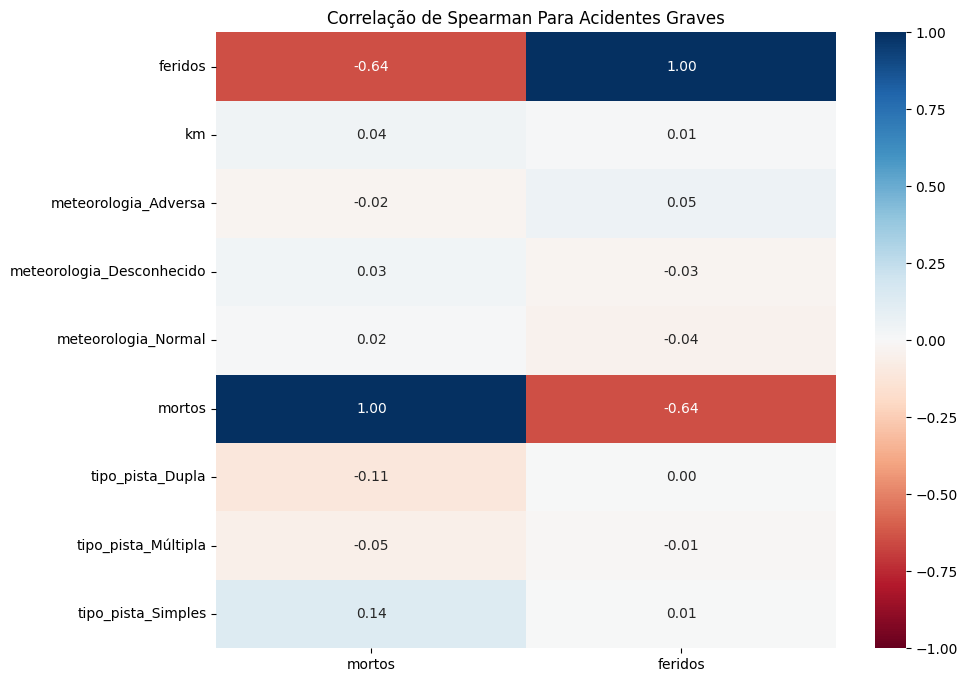

In [82]:
df_com_vitimas = df_encoded[df_encoded['mortos'] + df_encoded['feridos'] > 0].copy()

# Selecionando apenas as colunas relacionadas a vítimas, quilometragem, dia de semana e fase do dia
colunas_interesse = ['mortos', 'feridos', 'km'] + [c for c in df_encoded.columns if 'dia_semana' in c or 'fase_dia' in c or 'meteorologia' in c or 'tipo_pista' in c]
corr_com_vitimas = df_com_vitimas[colunas_interesse].corr(method='spearman')

plt.figure(figsize=(10, 8))

# Verificando a correlação de todas as variáveis apenas contra 'mortos' e 'feridos'
target_corr = corr_com_vitimas[['mortos', 'feridos']].sort_values(by='mortos', ascending=False)

# Ordenar o eixo y alfabeticamente
target_corr = target_corr.sort_index()

sns.heatmap(target_corr, annot=True, cmap='RdBu', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlação de Spearman Para Acidentes Graves')
plt.show()

### Análise de Componentes Principais (PCA)

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Selecionando apenas as colunas numéricas/dummies 
features = ['km'] + [c for c in df_encoded.columns if 'dia_semana' in c or 'fase_dia' in c or 'meteorologia' in c or 'tipo_pista' in c]

X = df_encoded[features]

# Normalização 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

A análise de PCA confirma a inviabilidade de reduzir a dimensionalidade. É demonstrado que cada componente traz uma informação única e relevante, não havendo variáveis discrepantemente dominantes. Sendo assim, os acidentes são fenômenos multifatoriais, que dependem de uma combinação equilibrada de diversos fatores.

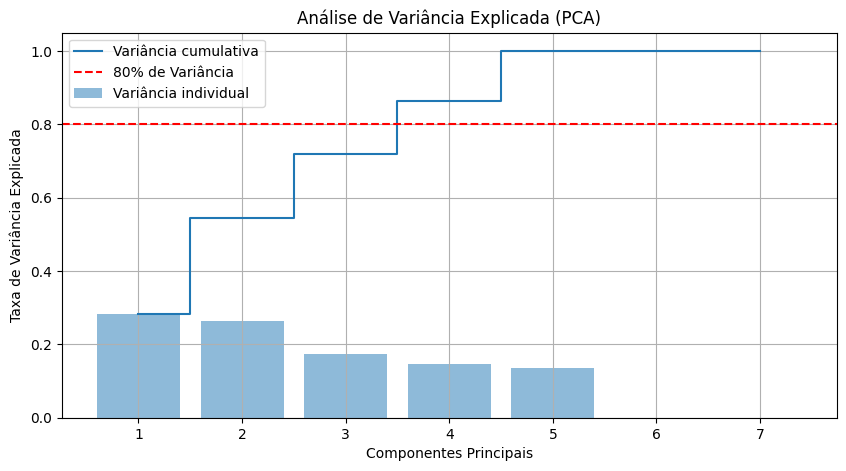

In [84]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)
exp_var_cumulativa = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(exp_var_cumulativa) + 1), pca.explained_variance_ratio_, alpha=0.5, align='center', label='Variância individual')
plt.step(range(1, len(exp_var_cumulativa) + 1), exp_var_cumulativa, where='mid', label='Variância cumulativa')
plt.ylabel('Taxa de Variância Explicada')
plt.xlabel('Componentes Principais')
plt.title('Análise de Variância Explicada (PCA)')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% de Variância')
plt.legend(loc='best')
plt.grid(True)
plt.show()